In [1]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 4.1 MB/s eta 0:00:00


In [2]:
# imports
import snntorch as snn
from snntorch import surrogate
from snntorch import backprop
from snntorch import functional as SF
from snntorch import utils
from snntorch import spikeplot as splt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import itertools

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torch.nn.utils.prune as prune
from torchvision import datasets, transforms, models

<ipython-input-2-67e1ca1d0cd3>:4: DeprecationWarning: The module snntorch.backprop will be deprecated in  a future release. Writing out your own training loop will lead to substantially faster performance.
  from snntorch import backprop


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Increased Resolution
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Increased Resolution
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [5]:
data_dir = "/kaggle/input/birds-vs-drone-dataset/BirdVsDrone"

In [ ]:
full_dataset = datasets.ImageFolder(root=data_dir)

# Split dataset into training and validation sets
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Apply respective transforms
train_dataset.dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)
test_dataset.dataset = datasets.ImageFolder(root=data_dir, transform=test_transforms)

# DataLoaders (Batch size increased from 8 to 32)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [7]:
len(train_loader), len(test_loader)

(83, 21)

In [ ]:
# neuron and simulation parameters
spike_grad = surrogate.fast_sigmoid(slope=15) # Decreased slope from 25 to 15
num_steps = 50

In [ ]:
# UPDATE SNN ARCHITECTURE CELL
width = 2
conv_filter = (5, 5)
pool = (4, 4) # Assuming you keep your notebook images at 128x128
beta = 0.93  

class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.batchnorm = nn.BatchNorm2d(3)

        self.conv1 = nn.Conv2d(3, 32 * width, kernel_size=conv_filter, padding="same")
        self.bn1 = nn.BatchNorm2d(32 * width)
        self.lif1 = snn.Leaky(beta=beta, learn_beta=True, learn_threshold=True)
        self.pool1 = nn.MaxPool2d(pool)

        self.conv2 = nn.Conv2d(32 * width, 32 * width, kernel_size=conv_filter, padding="same")
        self.bn2 = nn.BatchNorm2d(32 * width)
        self.lif2 = snn.Leaky(beta=beta, learn_beta=True, learn_threshold=True)
        self.pool2 = nn.MaxPool2d(pool)

        self.conv3 = nn.Conv2d(32 * width, 16 * width, kernel_size=conv_filter, padding="same")
        self.bn3 = nn.BatchNorm2d(16 * width)
        self.lif3 = snn.Leaky(beta=beta, learn_beta=True, learn_threshold=True)
        self.pool3 = nn.MaxPool2d(pool)

        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(16 * width * 4, 128) 
        self.bn_fc1 = nn.BatchNorm1d(128)
        self.lif_fc1 = snn.Leaky(beta=beta, learn_beta=True, learn_threshold=True)
        
        self.dropout = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(128, 2)
        self.lif_fc2 = snn.Leaky(beta=beta, learn_beta=True, learn_threshold=True)

    def forward(self, x):
        # ... (keep forward pass same as before but add self.bn_fc1 and self.dropout)

# UPDATE OPTIMIZER CELL
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-6)

for epoch in range(num_epochs):
    for data, targets in iter(train_loader):
        # ... forward pass ...
        optimizer.zero_grad()
        loss_val.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0) # Gradient Clip
        optimizer.step()
    scheduler.step() # Step outside the inner loop

In [10]:
torch.cuda.empty_cache()

In [11]:
data, targets = next(iter(train_loader))
data = data.to(device)
targets = targets.to(device)

for step in range(num_steps):
    spk_out, mem_out = net(data)

In [12]:
def forward_pass(net, num_steps, data):
  mem_rec = []
  spk_rec = []
  utils.reset(net)  # resets hidden states for all LIF neurons in net

  for step in range(num_steps):
      spk_out, mem_out = net(data)
      spk_rec.append(spk_out)
      mem_rec.append(mem_out)

  return torch.stack(spk_rec), torch.stack(mem_rec)

In [13]:
spk_rec, mem_rec = forward_pass(net, num_steps, data)

In [14]:
# already imported snntorch.functional as SF
loss_fn = SF.ce_rate_loss()

In [15]:
loss_val = loss_fn(spk_rec, targets)

print(f"The loss from an untrained network is {loss_val.item():.3f}")

The loss from an untrained network is 0.693


In [16]:
acc = SF.accuracy_rate(spk_rec, targets)

print(f"The accuracy of a single batch using an untrained network is {acc*100:.3f}%")

The accuracy of a single batch using an untrained network is 50.000%


In [17]:
def batch_accuracy(train_loader, net, num_steps):
  with torch.no_grad():
    total = 0
    acc = 0
    net.eval()

    train_loader = iter(train_loader)
    for data, targets in train_loader:
      data = data.to(device)
      targets = targets.to(device)
      spk_rec, _ = forward_pass(net, num_steps, data)

      acc += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)
      total += spk_rec.size(1)

  return acc/total

In [18]:
test_acc = batch_accuracy(test_loader, net, num_steps)

print(f"The total accuracy on the test set is: {test_acc * 100:.2f}%")

The total accuracy on the test set is: 48.80%


In [19]:
# --- Spike Sparsity Check (Optional, can be removed later) ---
data, targets = next(iter(train_loader))
data = data.to(device)
spk_rec, mem_rec = forward_pass(net, num_steps, data)
total_spikes = spk_rec.sum().item()
total_neurons = spk_rec.numel()
print(f"Spike activity ratio: {total_spikes / total_neurons:.4f}")

Spike activity ratio: 0.0000


In [ ]:
# Switch to AdamW
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
# Switch to Cosine Annealing
num_epochs = 300
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

loss_hist = []
test_acc_hist = []
counter = 0
best_acc = 0.0
best_model_path = "best_model.pt"

for epoch in range(num_epochs):
    for data, targets in iter(train_loader):
        data = data.to(device)
        targets = targets.to(device)

        net.train()
        spk_rec, _ = forward_pass(net, num_steps, data)
        loss_val = loss_fn(spk_rec, targets)

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        loss_hist.append(loss_val.item())

        if counter % 100 == 0:
            with torch.no_grad():
                net.eval()
                test_acc = batch_accuracy(test_loader, net, num_steps)
                print(f"Iteration {counter}, Test Acc: {test_acc * 100:.2f}%")
                test_acc_hist.append(test_acc.item())

                if test_acc > best_acc:
                    best_acc = test_acc
                    torch.save(net.state_dict(), best_model_path)
                    print(f"Saved best model with accuracy: {best_acc.item()*100:.2f}%")

        counter += 1
        
    # Step scheduler once per epoch
    scheduler.step()
    current_lr = scheduler.optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch} finished. Current LR: {current_lr:.6f}")

Iteration 0, Test Acc: 48.80%
Loss: 0.6931474208831787
Saved best model with accuracy: 0.4879518072289157
Current learning rate: 0.000100
Iteration 100, Test Acc: 65.06%
Loss: 0.7021558880805969
Saved best model with accuracy: 0.6506024096385542
Current learning rate: 0.000100
Iteration 200, Test Acc: 62.65%
Loss: 0.6904101967811584
Current learning rate: 0.000100
Iteration 300, Test Acc: 64.46%
Loss: 0.7366112470626831
Current learning rate: 0.000100
Iteration 400, Test Acc: 65.06%
Loss: 0.718510627746582
Current learning rate: 0.000100
Iteration 500, Test Acc: 58.43%
Loss: 0.6268768310546875
Current learning rate: 0.000100
Iteration 600, Test Acc: 74.10%
Loss: 0.6650334596633911
Saved best model with accuracy: 0.7409638554216867
Current learning rate: 0.000100
Iteration 700, Test Acc: 74.70%
Loss: 0.597896933555603
Saved best model with accuracy: 0.7469879518072289
Current learning rate: 0.000100
Iteration 800, Test Acc: 73.49%
Loss: 0.6813610792160034
Current learning rate: 0.000100

In [21]:
import os

model_size_mb = os.path.getsize(best_model_path)/ (1024 * 1024)
print(f"Model size: {model_size_mb:.2f} MB")

Model size: 0.06 MB


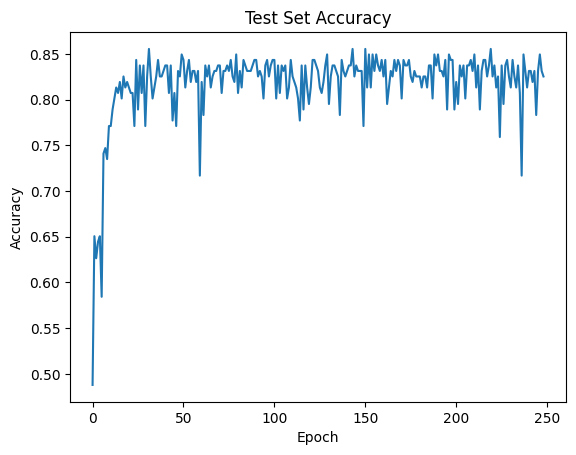

In [23]:
# Plot Loss
fig = plt.figure(facecolor="w")
plt.plot(test_acc_hist)
plt.title("Test Set Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()